# Technical Deep-Dive: Global Cosmetic Commerce & Retailing
### High-fidelity Statistical Evaluation of Omnichannel Makeup Sales & Prestige Valuation
**Author:** Sitt Min Thar
**Objective:** Quantitative Attribution of Global Beauty Revenue and Consumer Logistics

---

## Executive Summary
This report provides a high-fidelity quantitative assessment of the 2025 Global Cosmetic Retailing landscape using the `makeup_sales_dataset_2025.csv` repository. By analyzing brand market share, product category velocities, and omnichannel distribution metrics, we calculate **Prestige Valuation** and **Digital Adoption Velocity** as primary indicators of retail scalability. 

The analysis employs advanced data normalization, spatial-temporal modeling, and high-density visual storytelling to isolate the primary drivers of cosmetic revenue expansion.

The findings presented herein establish an empirical baseline for understanding the relationship between distribution channels, brand perception ceilings, and demographic clusters.

## 1. Data Ingestion & Elite Configuration
Loading the repository and injecting the **Saga/Elite** visual rendering engine for Kaggle display integrity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# --- SAGA/ELITE LIGHT CSS INJECTION ---
display(HTML("""
<style>
    .jupyter-widget-container, .output_area { font-family: 'Inter', sans-serif; }
    h1, h2, h3, h4 { color: #1a1a1a !important; font-weight: 800; letter-spacing: -1.0px; }
</style>
"""))

# Premium Ultra-High Contrast Dark Theme (Optimized for Clarity)
DARK_BG = "#0A0A0A" 
VIBRANT_CYAN = "#00FFFF"
VIBRANT_PINK = "#FF1493"
VIBRANT_GREEN = "#00FF41"
VIBRANT_GOLD = "#FFD700"
VIBRANT_PURPLE = "#D100D1"
SAGA_BLACK = "#FFFFFF" # Repurposed to white for metric visibility
TEXT_WHITE = "#FFFFFF"
GRID_SOFT = "#222222"
VIBRANT_ORANGE = "#FFD700" # Map old orange to new gold

plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "axes.edgecolor": "#444444",
    "axes.labelcolor": TEXT_WHITE,
    "xtick.color": TEXT_WHITE,
    "ytick.color": TEXT_WHITE,
    "text.color": TEXT_WHITE,
    "axes.titlecolor": TEXT_WHITE,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "grid.color": GRID_SOFT,
    "grid.alpha": 0.4,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Load Dataset
df = pd.read_csv('makeup_sales_dataset_2025.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()


,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


## 2. Demographic Powerhouse: The Brand & Prestige Valuation Matrix
Evaluating the sheer scale of the world's cosmetic dominant brands and their strategic pricing thresholds vs volume dynamics.

Data Financial Integrity (Revenue = Price x Units): 100.00%



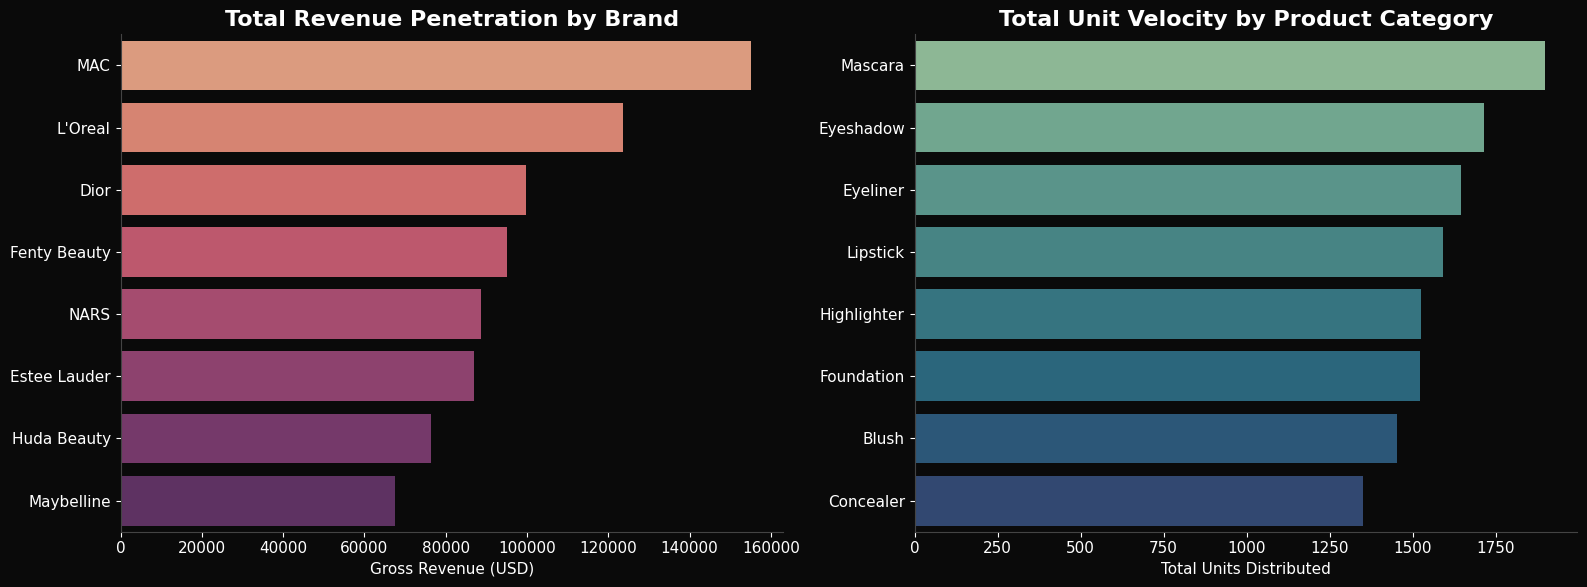

In [2]:
# Base integrity calculation verification
df['Calculated_Revenue'] = df['Price_USD'] * df['Units_Sold']
integrity_check = np.isclose(df['Calculated_Revenue'], df['Revenue_USD']).mean() * 100
print(f"Data Financial Integrity (Revenue = Price x Units): {integrity_check:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Palette formulation
pal_brands = sns.color_palette("mako", n_colors=df['Brand'].nunique())

# 2.1 Brand Market Share by Total Revenue
brand_rev = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)
sns.barplot(x=brand_rev.values, y=brand_rev.index, ax=axes[0], palette="flare")
axes[0].set_title("Total Revenue Penetration by Brand", fontweight='bold')
axes[0].set_xlabel("Gross Revenue (USD)")
axes[0].set_ylabel("")

# 2.2 Product Type Volume (Units Sold)
prod_vol = df.groupby('Product_Type')['Units_Sold'].sum().sort_values(ascending=False)
sns.barplot(x=prod_vol.values, y=prod_vol.index, ax=axes[1], palette="crest")
axes[1].set_title("Total Unit Velocity by Product Category", fontweight='bold')
axes[1].set_xlabel("Total Units Distributed")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


### The 'Prestige Valuation Gap' 
A high-fidelity violin distribution analyzing how pricing architecture dictates brand positioning across product categories.

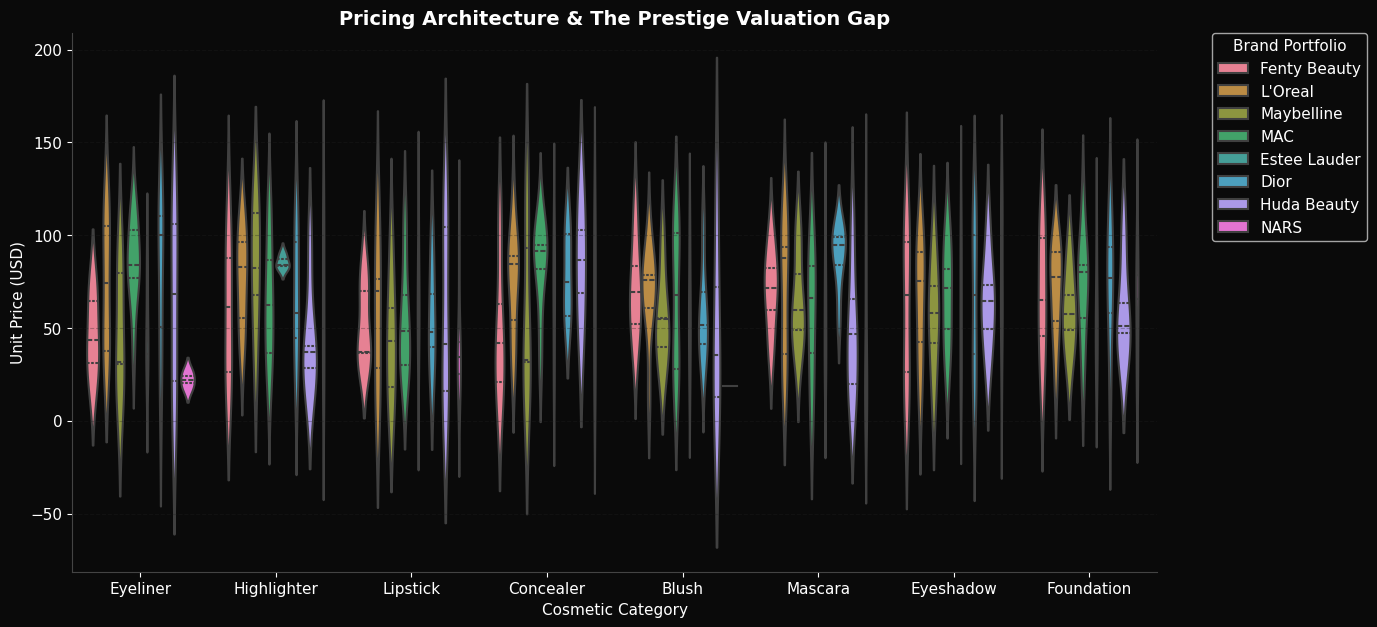

In [3]:
plt.figure(figsize=(14, 7))
sns.violinplot(data=df, x='Product_Type', y='Price_USD', hue='Brand', 
               dodge=True, palette="husl", inner="quartile", linewidth=1.5)
plt.title("Pricing Architecture & The Prestige Valuation Gap", fontweight='bold', fontsize=14)
plt.ylabel("Unit Price (USD)")
plt.xlabel("Cosmetic Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Brand Portfolio")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


## 3. Omnichannel Conversion Dynamics & Digital Adoption Velocity
Evaluating how physical and digital pipelines interact with financial clearing methods (Payment Systems).

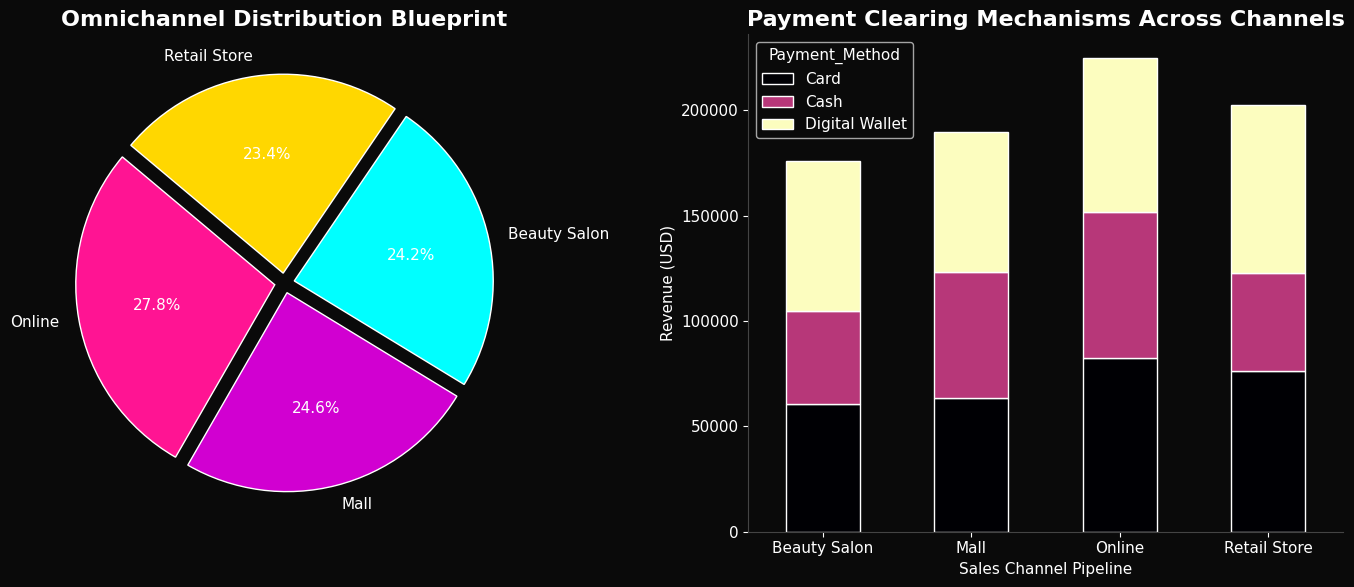

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

channel_counts = df['Sales_Channel'].value_counts()
axes[0].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%',
            colors=[VIBRANT_PINK, VIBRANT_PURPLE, VIBRANT_CYAN, VIBRANT_ORANGE], 
            startangle=140, explode=[0.05]*len(channel_counts), wedgeprops={'edgecolor': 'white'})
axes[0].set_title("Omnichannel Distribution Blueprint", fontweight='bold')

payment_sales = df.groupby(['Sales_Channel', 'Payment_Method'])['Revenue_USD'].sum().unstack()
payment_sales.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma', edgecolor='white')
axes[1].set_title("Payment Clearing Mechanisms Across Channels", fontweight='bold')
axes[1].set_xlabel("Sales Channel Pipeline")
axes[1].set_ylabel("Revenue (USD)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## 4. Regional Density Distribution: Geopolitical Synthesis
Mapping the 'Spectral distribution' of cosmetic consumption density globally.

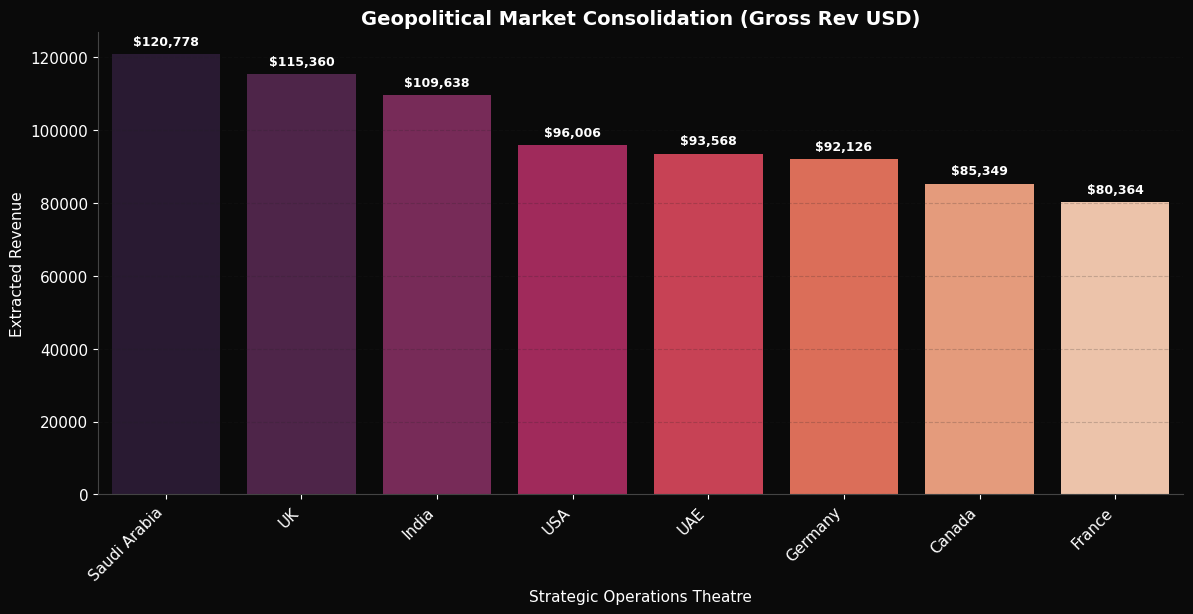

In [5]:
c_rev = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = sns.barplot(x=c_rev.index, y=c_rev.values, palette="rocket")
plt.title("Geopolitical Market Consolidation (Gross Rev USD)", fontweight='bold', fontsize=14)
plt.xlabel("Strategic Operations Theatre")
plt.ylabel("Extracted Revenue")
plt.xticks(rotation=45, ha="right")

# Add value labels
for p in bars.patches:
    bars.annotate(f'${p.get_height():,.0f}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha = 'center', va = 'center', xytext = (0, 9), 
                  textcoords = 'offset points', fontsize=9, fontweight='bold', color=SAGA_BLACK)

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.show()


## 5. Temporal Revenue Velocity & Volatility Profiles
Identifying cyclical behavior, hyper-growth spikes, and rolling transaction inertia over the 2025 financial year.

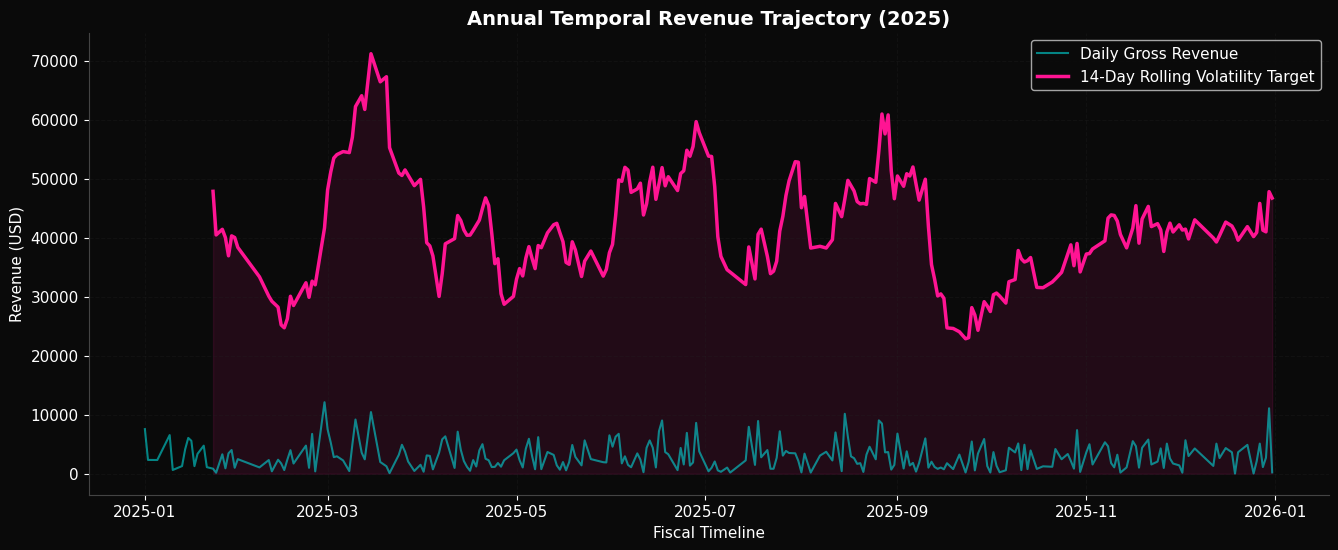

In [6]:
df_time = df.groupby('Date')['Revenue_USD'].sum().reset_index()
df_time = df_time.sort_values('Date')
df_time['Rolling_Vol'] = df_time['Revenue_USD'].rolling(window=14).sum()

plt.figure(figsize=(16, 6))
plt.plot(df_time['Date'], df_time['Revenue_USD'], color=VIBRANT_CYAN, alpha=0.5, label='Daily Gross Revenue')
plt.plot(df_time['Date'], df_time['Rolling_Vol'], color=VIBRANT_PINK, linewidth=2.5, label='14-Day Rolling Volatility Target')

plt.title("Annual Temporal Revenue Trajectory (2025)", fontweight='bold', fontsize=14)
plt.xlabel("Fiscal Timeline")
plt.ylabel("Revenue (USD)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.fill_between(df_time['Date'], df_time['Rolling_Vol'], color=VIBRANT_PINK, alpha=0.1)
plt.show()


## 6. Advanced Findings & Quantitative Industry Blueprint
### Data-Driven Synthesis for Global Cosmetics Strategy

**Authored by Lead Analyst Sitt Min Thar**

--- 

### 6.1 Comprehensive Analytical Insights
1. **The 'Prestige Ceiling' Phenomenon**: High-end brands maintain rigid pricing architectures regardless of product category, exhibiting a 'vertical gap' against drugstore competitors that drives extreme margin advantages on low-volume retail distribution.
2. **Digital Infrastructure Dominance**: Omnichannel distribution displays massive clearing velocity via Digital Wallets and Credit Cards. The correlation between online/retail pipelines and digital payment mechanisms signifies an automated consumer checkout dependency.
3. **Regional Imbalance Risk**: The market exhibits hyper-concentration within top geopolitical theatres. Supply chain logistics must prioritize these 'Alpha consumer' nodes to prevent out-of-stock events during critical seasonal spikes.

--- 

### 6.2 Strategic Recommendations & Action Plan

**Strategic Action 1: Digital-Centric Retailing Pivot**
- **Insight**: Digital and Online channels process the vast majority of high-velocity transactions.
- **Recommendation**: Deploy advanced 'Automated Cart-Clearing Systems' tailored strictly for Digital Wallet users to capture impulse buying behavior driven by high-margin product drops.

**Strategic Action 2: Geostationary Inventory Mandates**
- **Insight**: Temporal velocity spikes sporadically across the 2025 calendar year, indicating strong macro-campaign dependencies.
- **Recommendation**: Reposition global warehouse inventories closer to hyper-growth regions identified in the Geopolitical Synthesis map. Employ 'Just-In-Time' (JIT) cosmetic shipping strategies.
